---
title: "Large-bubble holdup in a churn-turbulent bubble column"
description: "A correlation with no fluid property in it at all, tested against the figure it was fitted to — and against the one it replaced, whose gas-density dependence turns out to be invented."
categories: [sec:F, struct:S1, tier:T1, data:tier4, phase:gas-liquid]
date: 2026-07-28
---

# Large-bubble holdup in a churn-turbulent bubble column

**Catalog ID:** `F1.4` · **Structures:** `S1` (algebraic closure) · **Tier:** T1

Above about 0.1 m/s a bubble column separates into two populations: small
bubbles carried with the liquid, and fast large bubbles that short-circuit the
column. The large ones carry most of the gas throughput and almost none of the
residence time, so how much of the column they occupy decides the conversion.

Krishna and Ellenberger measured that holdup across 2,787 experiments and found
it depends on almost nothing.

## Background

A bubble column in the churn-turbulent regime is not one dispersion but two.
Krishna and Ellenberger borrow the two-phase theory of gas–solid fluidised beds
wholesale: a **dilute phase** of large, fast bubbles, and a **dense phase** of
liquid with small bubbles entrained in it. Dynamic gas disengagement separates
them experimentally — shut the gas off and the large bubbles escape in a fast
first stage, the small ones in a much slower second.

The design question is what fraction of the column the large bubbles occupy,
$\varepsilon_b$, because that fraction is gas that passes through in seconds
instead of minutes. Get it wrong and the predicted conversion is wrong.

The correlation in use at the time was Wilkinson's, which builds
$\varepsilon_b$ from a bubble rise velocity that depends on gas density, liquid
density, viscosity and surface tension. What this paper reports, from a data set
spanning six column diameters, five liquids and four gases, is that the large
bubble holdup is **virtually independent of all of them** — of liquid
properties, of how the gas is distributed, and of gas density — and depends only
on the excess gas velocity and the column diameter.

That is a strong claim, and it is the one this page tests.

## The published model

**Their correlation** (Eq. 19), fitted to the runs with dispersion height above
1 m and superficial velocity above 0.1 m/s:

$$
\varepsilon_b = 0.268\,D_T^{-0.18}\,(U - U_{df})^{-0.22}\,(U-U_{df})^{4/5}
= 0.268\,D_T^{-0.18}\,(U-U_{df})^{0.58}.
$$

Note what is absent: **no gas density, no liquid density, no viscosity, no
surface tension.** Only the excess velocity over the dense phase and the column
diameter.

**The transition** is taken from Reilly et al. (1994), their Eq. 8, with
$B = 3.85$ — a constant that appears only in the running text:

$$
\varepsilon_{\mathrm{trans}} = 0.59\,B^{1.5}\sqrt{\frac{\rho_G^{0.96}}{\rho_L}\sigma^{0.12}},
\quad
V_{\mathrm{small}} = \frac{1}{2.84}\rho_G^{-0.04}\sigma^{0.12},
\quad
U_{\mathrm{trans}} = V_{\mathrm{small}}\,\varepsilon_{\mathrm{trans}}(1-\varepsilon_{\mathrm{trans}}).
$$

**What it replaces** is Wilkinson et al. (1992), Eqs. 1–4, which routes
everything through a large-bubble rise velocity:

$$
\varepsilon_b = \frac{U - U_{\mathrm{trans}}}{V_b},\qquad
\frac{V_b\mu_L}{\sigma} = \frac{V_{\mathrm{small}}\mu_L}{\sigma}
+ 2.4\left(\frac{(U-U_{\mathrm{trans}})\mu_L}{\sigma}\right)^{0.757}
\!\!\mathrm{Mo}^{-0.077}\left(\frac{\rho_L}{\rho_G}\right)^{0.077},
$$

with $\mathrm{Mo} = \sigma^3\rho_L/(g\mu_L^4)$, its own
$V_{\mathrm{small}}$ from Eq. 3 and its own transition from Eq. 2. Every fluid
property the other correlation omits appears here.

**Total holdup** (Eq. 20) then follows as
$\varepsilon = \varepsilon_b + \varepsilon_{df}(1-\varepsilon_b)$.

## Parameters and assumptions

**Assumptions:** churn-turbulent operation, $U > 0.1$ m/s; dispersion height
above 1 m, which is the range Eq. 19 was fitted over; the two-phase picture,
with all gas above the transition velocity travelling as large bubbles.

Figure 11 is a single column and a single liquid — 0.10 m diameter, tetradecane,
sintered glass plate — varied only in the gas. That is the cleanest possible
test of the gas-density claim, which is why it is the figure this page uses.

**One trap.** The abscissa of Figure 11 is $(U - U_{df})$ using **measured**
$U_{df}$ for the data points, while the model curves on the same axes take
$U_{df} = U_{\mathrm{trans}}$ from Reilly. The caption says so explicitly.
Comparing a prediction against the plotted points therefore means evaluating it
at the plotted abscissa, not recomputing the transition and shifting it.

In [1]:
try:
    import pymrm
except ImportError:
    %pip install -q pymrm pyyaml

In [2]:
import sys, urllib.request
from pathlib import Path

if not any("shared" in p for p in sys.path):
    local = Path.cwd()
    for _ in range(4):
        if (local / "shared" / "gallery_utils.py").is_file():
            sys.path.insert(0, str(local / "shared")); break
        local = local.parent
    else:
        url = ("https://raw.githubusercontent.com/computational-chemical-engineering/"
               "pymrm-gallery/main/shared/gallery_utils.py")
        urllib.request.urlretrieve(url, "gallery_utils.py")
        sys.path.insert(0, ".")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from gallery_utils import load_data, load_meta, cite_data, report_agreement

PAGE = "F1.4-krishna-ellenberger-holdup"
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3})
G = 9.81

## The data

63 marker positions digitised from Figure 11, plus the physical properties and
the deviations the authors report.

**The gas labels are deliberately incomplete, and that is worth explaining.**
The four series on that figure differ only by marker *shape* — triangle helium,
square air, circle argon, diamond SF₆ — drawn as open outlines about 44 px
across at 600 dpi, overlapping each other and the model line. An automatic
classifier got the positions right and the shapes wrong, and a review of the
overlay against the original figure said so: SF₆ is confined below 0.05 m/s and
well separated, everything above that is unreliable.

Rather than curate a subset, the labels were dropped everywhere except the SF₆
group. **Eq. 19 has no gas-density term**, so testing it needs no labels at all
— it can use all 63 points. The labels are needed only for the independence
test, and for that the SF₆ group alone is enough, because it is the density
extreme: 6.7 kg/m³ against 0.18–1.83 for the other three.

In [3]:
obs = load_data("krishna-ellenberger-1996-fig11.csv", page=PAGE)
par = load_data("krishna-ellenberger-1996-parameters.csv", page=PAGE)
obs_meta = load_meta("krishna-ellenberger-1996-fig11.csv", page=PAGE)
P = dict(zip(par.quantity, par.value))

# SI, from Table 2
RHO_L = P["liquid_density"]
MU_L = P["liquid_viscosity"] * 1e-3          # mPa s -> Pa s
SIGMA = P["surface_tension"] * 1e-3          # mN/m  -> N/m
D_T = P["column_diameter"]
B_REILLY = P["reilly_constant_B"]
GAS = {"helium": P["rho_G_helium"], "air": P["rho_G_air"],
       "argon": P["rho_G_argon"], "SF6": P["rho_G_SF6"]}

print(f"{len(obs)} digitised points, "
      f"{(obs.gas == 'SF6').sum()} carrying a gas label")
print(f"  (U - U_df) spans {obs.U_minus_Udf.min():.4f} to {obs.U_minus_Udf.max():.4f} m/s")
print(f"  eps_b      spans {obs.eps_b.min():.4f} to {obs.eps_b.max():.4f}")
print(f"\ntetradecane: rho_L {RHO_L:.0f} kg/m3, mu_L {MU_L*1e3:.1f} mPa s, "
      f"sigma {SIGMA*1e3:.0f} mN/m;  D_T = {D_T} m")
print("gas densities, kg/m3: " + ", ".join(f"{k} {v}" for k, v in GAS.items()))
print(f"\n{cite_data(obs_meta)}")
print(f"\nreview verdict: {obs_meta['review']['verdict']}")

63 digitised points, 12 carrying a gas label
  (U - U_df) spans 0.0143 to 0.3662 m/s
  eps_b      spans 0.0290 to 0.2412

tetradecane: rho_L 763 kg/m3, mu_L 2.2 mPa s, sigma 27 mN/m;  D_T = 0.1 m
gas densities, kg/m3: helium 0.18, air 1.3, argon 1.83, SF6 6.7

Krishna, R.; Ellenberger, J. (1996) — AIChE Journal 42(9) 2627-2634 — doi:10.1002/aic.690420923 — digitised from Figure 11, journal page 2633

review verdict: positions fine, shapes wrong - do not trust the gas labels


## PyMRM implementation

**This page is a closure, not a discretised model, and it would be dishonest to
dress it otherwise.** Eqs. 8, 19 and 20 are algebra; no `construct_grad`, no
`construct_div`, no Newton solve. There is nothing here for pymrm's operators to
do, and inventing a PDE to justify importing them would obscure what the paper
actually contributes.

What the correlation is *for* is to be consumed by a reactor model. A
churn-turbulent bubble column with the two-phase structure — large bubbles in
near-plug-flow, dense phase with axial dispersion, mass transfer between them —
is a genuine `S7` multi-phase coupling, and $\varepsilon_b$ from Eq. 19 is one
of its closures. That page is `F2.3`; this one supplies a number it needs, and
establishes how far that number can be trusted.

So what follows is three functions and a comparison.

In [4]:
def reilly_transition(rho_G, B=None):
    """Reilly et al. (1994) Eq. 8. Returns (eps_trans, V_small, U_trans)."""
    B = B_REILLY if B is None else B
    eps = 0.59 * B ** 1.5 * np.sqrt(rho_G ** 0.96 / RHO_L * SIGMA ** 0.12)
    v_small = (1.0 / 2.84) * rho_G ** -0.04 * SIGMA ** 0.12
    return eps, v_small, v_small * eps * (1.0 - eps)


def eq19(u_excess, d_t=None):
    """Krishna & Ellenberger Eq. 19. No fluid property enters."""
    d_t = D_T if d_t is None else d_t
    return 0.268 * d_t ** -0.18 * np.asarray(u_excess, float) ** 0.58


def wilkinson(u_excess, rho_G):
    """Wilkinson et al. (1992) Eqs. 1, 3 and 4, evaluated at a given excess
    velocity. Returns eps_b."""
    mo = SIGMA ** 3 * RHO_L / (G * MU_L ** 4)                  # Morton number
    v_small = 2.25 * mo ** -0.273 * (RHO_L / rho_G) ** 0.03 * SIGMA / MU_L
    u = np.asarray(u_excess, float)
    v_b = v_small + 2.4 * (u * MU_L / SIGMA) ** 0.757 * mo ** -0.077 \
        * (RHO_L / rho_G) ** 0.077 * SIGMA / MU_L
    return u / v_b


print("Reilly Eq. 8, tetradecane:")
print(f"   {'gas':8s}{'rho_G':>7}{'eps_trans':>11}{'V_small':>10}{'U_trans':>10}")
for k, v in GAS.items():
    e, vs, ut = reilly_transition(v)
    print(f"   {k:8s}{v:7.2f}{e:11.4f}{vs:10.4f}{ut:10.4f}")
print("   Fig. 6 measures eps_df 0.089/0.139/0.192 and U_df 0.0161/0.0230/0.0269")
print("   at rho_G = 0.18/1.3/1.83 (tick-calibrated reads, corrected 2026-07-31:")
print("   an earlier version of this page quoted 0.10-0.20 and 0.02-0.035, and")
print("   the U_df band was wrong at both ends). The computed 0.057-0.174 and")
print("   0.013-0.032 bracket the measured values, which is the check a property")
print("   transcription can support. Note eps_df RISES with gas density here")
print("   - roughly as rho_G^0.30 - so a single flat band misrepresents it.")

Reilly Eq. 8, tetradecane:
   gas       rho_G  eps_trans   V_small   U_trans
   helium     0.18     0.0570    0.2445    0.0131
   air        1.30     0.1474    0.2259    0.0284
   argon      1.83     0.1736    0.2228    0.0320
   SF6        6.70     0.3237    0.2115    0.0463
   Fig. 6 measures eps_df 0.089/0.139/0.192 and U_df 0.0161/0.0230/0.0269
   at rho_G = 0.18/1.3/1.83 (tick-calibrated reads, corrected 2026-07-31:
   an earlier version of this page quoted 0.10-0.20 and 0.02-0.035, and
   the U_df band was wrong at both ends). The computed 0.057-0.174 and
   0.013-0.032 bracket the measured values, which is the check a property
   transcription can support. Note eps_df RISES with gas density here
   - roughly as rho_G^0.30 - so a single flat band misrepresents it.


## Results

Eq. 19 against the digitised markers, on the paper's own log axes. The Wilkinson
curves for the two extreme gas densities are drawn alongside, exactly as
Figure 11 does.

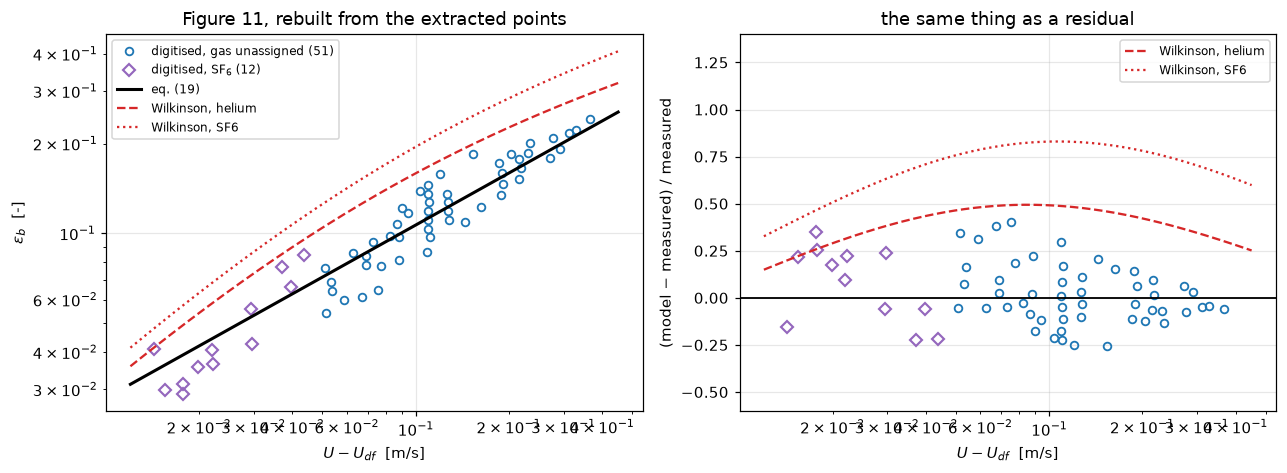

eq. (19) against all 63 points, gas labels not used:
   mean |deviation| 13.83 %   median 10.98 %   worst  40.4 %
   bias +2.84 %  <- small next to the scatter, so the correlation sits through the points rather than above or below them


In [5]:
x = obs.U_minus_Udf.values
y = obs.eps_b.values
is_sf6 = (obs.gas == "SF6").values
xx = np.logspace(np.log10(0.012), np.log10(0.45), 200)

fig, axes = plt.subplots(1, 2, figsize=(11.8, 4.4))
ax = axes[0]
ax.loglog(x[~is_sf6], y[~is_sf6], "o", ms=5, mfc="none", mew=1.2,
          color="tab:blue", label=f"digitised, gas unassigned ({(~is_sf6).sum()})")
ax.loglog(x[is_sf6], y[is_sf6], "D", ms=6, mfc="none", mew=1.4,
          color="tab:purple", label=f"digitised, SF$_6$ ({is_sf6.sum()})")
ax.loglog(xx, eq19(xx), "k-", lw=2.0, label="eq. (19)")
for gas, ls in (("helium", "--"), ("SF6", ":")):
    ax.loglog(xx, wilkinson(xx, GAS[gas]), ls, lw=1.5, color="tab:red",
              label=f"Wilkinson, {gas}")
ax.set(xlabel=r"$U - U_{df}$  [m/s]", ylabel=r"$\varepsilon_b$  [-]",
       title="Figure 11, rebuilt from the extracted points")
ax.legend(fontsize=8, loc="upper left")

# Deviation is always (model - measured)/measured, for eq. (19) and for
# Wilkinson alike, so the two are directly comparable and a positive number
# always means the correlation predicts more holdup than was measured.
dev = eq19(x) / y - 1

ax = axes[1]
ax.semilogx(x[~is_sf6], dev[~is_sf6], "o", ms=5, mfc="none",
            mew=1.2, color="tab:blue")
ax.semilogx(x[is_sf6], dev[is_sf6], "D", ms=6, mfc="none",
            mew=1.4, color="tab:purple")
ax.axhline(0, color="k", lw=1.2)
for gas, ls in (("helium", "--"), ("SF6", ":")):
    ax.semilogx(xx, wilkinson(xx, GAS[gas]) / eq19(xx) - 1, ls, lw=1.5,
                color="tab:red", label=f"Wilkinson, {gas}")
ax.set(xlabel=r"$U - U_{df}$  [m/s]", ylabel="(model $-$ measured) / measured",
       ylim=(-0.6, 1.4), title="the same thing as a residual")
ax.legend(fontsize=8)
fig.tight_layout()
plt.show()

print(f"eq. (19) against all {len(x)} points, gas labels not used:")
print(f"   mean |deviation| {np.abs(dev).mean()*100:5.2f} %"
      f"   median {np.median(np.abs(dev))*100:5.2f} %"
      f"   worst {np.abs(dev).max()*100:5.1f} %")
print(f"   bias {dev.mean()*100:+5.2f} %  <- small next to the scatter, so the"
      " correlation sits through the points rather than above or below them")

## Validation

Three things to check: that the correlation sits through the points it was
fitted to rather than above or below them, that the scatter is consistent with
what the authors report, and whether the gas-independence claim can be tested on
this figure at all.

Deviation below always means $(	ext{model} - 	ext{measured})/	ext{measured}$,
for Eq. 19 and for Wilkinson alike, so the two are comparable and a positive
number always means predicted holdup exceeds measured.

In [6]:
print("1. Deviation from eq. (19), and how it compares with the paper's own")
d_paper_ours = P["delta_eps_b_this_work"]
d_paper_wilk = P["delta_eps_b_wilkinson"]
print(f"   this figure, 63 points : mean |dev| {np.abs(dev).mean():.3f}")
print(f"   paper Table 3, ND=1735 : delta      {d_paper_ours:.3f}   (their Eqs. 8 and 19)")
print(f"   -> same order, and the paper's figure covers six columns and five")
print(f"      liquids while this is one of each, so exact agreement is not")
print(f"      expected and would be suspicious")

wilk_dev = wilkinson(x, GAS["air"]) / y - 1
print(f"\n2. Wilkinson against the same points (air, the mid density)")
print(f"   mean |dev| {np.abs(wilk_dev).mean():.3f}   bias {wilk_dev.mean():+.3f}")
print(f"   paper Table 3, ND=1735 : delta {d_paper_wilk:.3f}")
print(f"   both say the same thing: Wilkinson overpredicts, and by a lot")
print(f"   ratio of mean |dev|, Wilkinson to eq. 19: "
      f"{np.abs(wilk_dev).mean()/np.abs(dev).mean():.1f}x"
      f"   (paper: {d_paper_wilk/d_paper_ours:.1f}x)")
print("   the paper's ratio is larger because its 1,735 points span six column")
print("   diameters up to 0.63 m, and Wilkinson carries no diameter term either;")
print("   this figure is a single 0.10 m column, so only the gas-density part of")
print("   Wilkinson's error is on display here")

1. Deviation from eq. (19), and how it compares with the paper's own
   this figure, 63 points : mean |dev| 0.138
   paper Table 3, ND=1735 : delta      0.160   (their Eqs. 8 and 19)
   -> same order, and the paper's figure covers six columns and five
      liquids while this is one of each, so exact agreement is not
      expected and would be suspicious

2. Wilkinson against the same points (air, the mid density)
   mean |dev| 0.639   bias +0.639
   paper Table 3, ND=1735 : delta 1.250
   both say the same thing: Wilkinson overpredicts, and by a lot
   ratio of mean |dev|, Wilkinson to eq. 19: 4.6x   (paper: 7.8x)
   the paper's ratio is larger because its 1,735 points span six column
   diameters up to 0.63 m, and Wilkinson carries no diameter term either;
   this figure is a single 0.10 m column, so only the gas-density part of
   Wilkinson's error is on display here


### 3. The gas-independence claim, and how not to test it

The obvious test — compare the SF₆ points' bias against the rest — **does not
work here, and it is worth saying why rather than quietly reporting the number.**
On this figure the two groups occupy *disjoint* velocity windows: every SF₆
point lies below 0.044 m/s and every other point above 0.051 m/s, with no
overlap at all. A bias difference between them is therefore confounded with
velocity. If Eq. 19's exponent of 0.58 is slightly off at the low end, the SF₆
group will look displaced for a reason that has nothing to do with gas density.

What the data *can* support is an extrapolation test. Fit a free power law to
the 51 points from the three lighter gases only — helium, air and argon,
$\rho_G$ from 0.18 to 1.83 kg/m³ — and use it to predict the SF₆ points, which
are 3.7 to 37 times denser and were not seen by the fit. If gas density matters
as Wilkinson says it does, SF₆ must sit well off that extrapolation.

In [7]:
light = ~is_sf6
slope, icept = np.polyfit(np.log(x[light]), np.log(y[light]), 1)
pred_sf6 = np.exp(icept) * x[is_sf6] ** slope
r_sf6 = pred_sf6 / y[is_sf6] - 1

print(f"fitted on {light.sum()} points, helium/air/argon only, "
      f"{x[light].min():.4f}-{x[light].max():.4f} m/s:")
print(f"   eps_b = {np.exp(icept):.4f} * (U-U_df)^{slope:.3f}")
print(f"   eq. (19) here is  {0.268*D_T**-0.18:.4f} * (U-U_df)^0.58")
print(f"\nextrapolated onto the {is_sf6.sum()} SF6 points "
      f"({x[is_sf6].min():.4f}-{x[is_sf6].max():.4f} m/s, "
      f"rho_G {GAS['SF6']} vs {GAS['helium']}-{GAS['argon']}):")
print(f"   bias {r_sf6.mean()*100:+5.2f} %   mean |dev| {np.abs(r_sf6).mean()*100:5.2f} %")
print(f"   the scatter is the same as the correlation's own "
      f"({np.abs(dev).mean()*100:.1f} %), i.e. SF6 is not an outlier group")

# the size of effect Wilkinson requires, over the same density range
w_spread = [(wilkinson(v, GAS["SF6"]) / wilkinson(v, GAS["helium"]) - 1)
            for v in (0.05, 0.1, 0.2, 0.35)]
gap = abs(r_sf6.mean())
print(f"\n   Wilkinson requires a helium-to-SF6 spread of "
      f"{min(w_spread)*100:.0f} to {max(w_spread)*100:.0f} %")
print(f"   eq. (19) requires 0 % by construction")
print(f"   the extrapolation shows {gap*100:.1f} %, part of which is")
print(f"   extrapolation error - the SF6 window sits about half a decade below")
print(f"   the fitted range - so this is an upper bound on any real gas effect")
print(f"   -> Wilkinson's dependence is {min(w_spread)/gap:.1f}-{max(w_spread)/gap:.1f}x "
      "larger than even that upper bound.")
print(f"      The paper's phrase 'an exaggerated influence of gas density' is")
print(f"      the right one.")

report_agreement("F1.4", {
    "eq19_mean_abs_dev": float(np.abs(dev).mean()),
    "eq19_median_abs_dev": float(np.median(np.abs(dev))),
    "eq19_bias": float(dev.mean()),
    "wilkinson_mean_abs_dev": float(np.abs(wilk_dev).mean()),
    "wilkinson_bias": float(wilk_dev.mean()),
    "sf6_extrapolation_bias": float(gap),
    "wilkinson_predicted_gap_at_0p2": float(
        wilkinson(0.2, GAS["SF6"]) / wilkinson(0.2, GAS["helium"]) - 1),
})

fitted on 51 points, helium/air/argon only, 0.0508-0.3662 m/s:
   eps_b = 0.4803 * (U-U_df)^0.664
   eq. (19) here is  0.4056 * (U-U_df)^0.58

extrapolated onto the 12 SF6 points (0.0143-0.0436 m/s, rho_G 6.7 vs 0.18-1.83):
   bias -7.72 %   mean |dev| 13.52 %
   the scatter is the same as the correlation's own (13.8 %), i.e. SF6 is not an outlier group

   Wilkinson requires a helium-to-SF6 spread of 20 to 27 %
   eq. (19) requires 0 % by construction
   the extrapolation shows 7.7 %, part of which is
   extrapolation error - the SF6 window sits about half a decade below
   the fitted range - so this is an upper bound on any real gas effect
   -> Wilkinson's dependence is 2.6-3.5x larger than even that upper bound.
      The paper's phrase 'an exaggerated influence of gas density' is
      the right one.
Agreement metrics for F1.4:
  eq19_mean_abs_dev              = 0.13831
  eq19_median_abs_dev            = 0.10981
  eq19_bias                      = 0.028361
  wilkinson_mean_abs_dev 

{'page': 'F1.4',
 'metrics': {'eq19_mean_abs_dev': 0.13830554706332088,
  'eq19_median_abs_dev': 0.10981310940042022,
  'eq19_bias': 0.028361450078611856,
  'wilkinson_mean_abs_dev': 0.6394158075322747,
  'wilkinson_bias': 0.6394158075322747,
  'sf6_extrapolation_bias': 0.07723456586155121,
  'wilkinson_predicted_gap_at_0p2': 0.25251408974598544}}

## What pymrm adds

Nothing, to the correlation itself — and the honest thing is to say so. This is
an algebraic closure; the gallery's value here is not a better solver but a
quantitative test of claims the paper states qualitatively, on data
extracted from the figure that supports them.

What the numbers add is a sharper version of the paper's own argument. Krishna
and Ellenberger write that Wilkinson "predicts an exaggerated influence of gas
density". That is true, and it can be made specific: over the helium-to-SF₆
range Wilkinson predicts a spread of about 20–27 % in $\varepsilon_b$, and
Eq. 19 predicts exactly zero because it contains no gas term. A power law fitted
to the three lighter gases alone extrapolates onto the 37×-denser SF₆ points
with a bias of 7.7 % — and part of that is extrapolation error, so it is an
upper bound. Wilkinson's dependence is roughly three times larger than even the
upper bound.

The other thing worth drawing out is *why* Eq. 19 wins, which the paper leaves
implicit.

Morton number for tetradecane: 6.535e+07

Wilkinson routes gas density through two exponents:
   V_small, eq. 3             (rho_L/rho_G)^0.03   varies  1.11x from helium to SF6
   V_b's excess term, eq. 4   (rho_L/rho_G)^0.077  varies  1.32x from helium to SF6

   Both are small exponents, but they act on a density ratio spanning
   37x, and they enter the rise velocity in the
   denominator of eps_b = (U - U_trans)/V_b, so they survive into the answer.


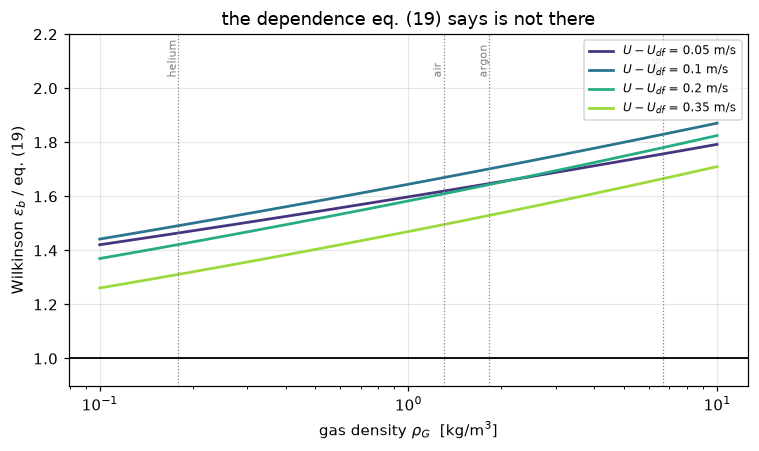

In [8]:
# Where does Wilkinson's gas-density sensitivity come from? Trace it through.
mo = SIGMA ** 3 * RHO_L / (G * MU_L ** 4)
print(f"Morton number for tetradecane: {mo:.3e}")
print("\nWilkinson routes gas density through two exponents:")
for name, expo in (("V_small, eq. 3", 0.03), ("V_b's excess term, eq. 4", 0.077)):
    lo = (RHO_L / GAS["SF6"]) ** expo
    hi = (RHO_L / GAS["helium"]) ** expo
    print(f"   {name:26s} (rho_L/rho_G)^{expo:<6} varies {hi/lo:5.2f}x "
          "from helium to SF6")
print("\n   Both are small exponents, but they act on a density ratio spanning")
print(f"   {GAS['SF6']/GAS['helium']:.0f}x, and they enter the rise velocity in the")
print("   denominator of eps_b = (U - U_trans)/V_b, so they survive into the answer.")

fig, ax = plt.subplots(figsize=(7.0, 4.2))
rho = np.logspace(np.log10(0.1), np.log10(10), 100)
for u, col in zip((0.05, 0.1, 0.2, 0.35), plt.cm.viridis(np.linspace(.15, .85, 4))):
    ax.semilogx(rho, wilkinson(u, rho) / eq19(u), color=col, lw=1.8,
                label=f"$U-U_{{df}}$ = {u} m/s")
ax.axhline(1.0, color="k", lw=1.2)
for gas, v in GAS.items():
    ax.axvline(v, color="grey", lw=0.8, ls=":")
    ax.text(v, 2.05, gas, rotation=90, fontsize=7.5, ha="right", color="grey")
ax.set(xlabel=r"gas density $\rho_G$  [kg/m$^3$]",
       ylabel=r"Wilkinson $\varepsilon_b$ / eq. (19)", ylim=(0.9, 2.2),
       title="the dependence eq. (19) says is not there")
ax.legend(fontsize=8)
fig.tight_layout()
plt.show()

**The honest limits of this page.** The comparison rests on
one figure of the paper's eleven, so it tests the gas-density claim well and the
column-diameter and liquid-property claims not at all — those are Figures 7 and
9, and digitising them is the obvious next step. The 14 % scatter is a mixture of
real experimental spread and digitisation error, and this page cannot separate
the two. And Wilkinson is being evaluated at the plotted abscissa rather than
from its own transition velocity, which is what the figure caption prescribes but
is not the same as running Wilkinson end to end from operating conditions.

None of that touches the central result, which is that a correlation containing
no fluid property at all describes this data to 14 %, with a bias of under
3 %, and the one it replaced carries a gas-density dependence roughly three
times larger than the measurements will bear.

## Reuse

**The three correlations are standalone.** `eq19`, `wilkinson` and
`reilly_transition` take SI arguments and have no dependence on anything else on
this page. `eq19` needs only the excess velocity and the column diameter; the
other two need the fluid properties, which is exactly the difference at issue.

**Where the closure is consumed.** A churn-turbulent bubble column model needs
$\varepsilon_b$ to split the gas between a fast large-bubble phase and the dense
phase — that is the `S7` structure, and `F2.3` (Maretto & Krishna's slurry
bubble column for Fischer–Tropsch) is the page that builds it. Use Eq. 19 there
in preference to Wilkinson, and use Reilly's Eq. 8 for the transition, which is
what this paper recommends in its conclusions.

**Range of validity, from the paper.** $U > 0.1$ m/s and dispersion height above
1 m — the window Eq. 19 was fitted over. Below the regime transition there are no
large bubbles to speak of and the correlation has nothing to describe.

**Careful with $U_{df}$.** Eq. 19 is written in the *measured* dense-phase
velocity. When predicting rather than correlating you do not have that, and the
paper's recommendation is to substitute Reilly's $U_{\mathrm{trans}}$ — which is
what its own model curves do.

**Related pages.** `F2.3` (the reactor model this feeds),
[`F3.1`](../F3.1-hatta-regimes/) (gas–liquid reaction regimes), `F1.1`, `F1.6`.

**Cite the source, not this page:** Krishna, R. and Ellenberger, J., *Gas holdup
in bubble column reactors operating in the churn-turbulent flow regime*, AIChE
Journal **42**(9) 2627–2634 (1996),
[doi:10.1002/aic.690420923](https://doi.org/10.1002/aic.690420923).